
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades Carlos! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo al separar la importación de bibliotecas de la carga de los datasets! Esto mejora la estructura y claridad de tu código.

</div>

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

**Tip:** Si no usas `print()` la tabla se vera mejor.

In [3]:
print(traffic.head())

  Country       City            UpdateTimeUTC  JamsDelay  TrafficIndexLive  \
0     ARE  abu-dhabi  2025-01-13 04:01:30.001      650.7              36.0   
1     ARE  abu-dhabi  2025-01-13 03:46:00.000      540.4              30.0   
2     ARE  abu-dhabi  2025-01-13 02:46:30.000       71.8               7.0   
3     ARE  abu-dhabi  2025-01-13 01:46:30.001        8.2               2.0   
4     ARE  abu-dhabi  2025-01-13 00:01:30.000        1.1               1.0   

   JamsLengthInKms  JamsCount  TrafficIndexWeekAgo     UpdateTimeUTCWeekAgo  \
0            109.1      162.0                 30.0  2025-01-06 04:01:30.000   
1            101.4      136.0                 27.0  2025-01-06 03:46:30.001   
2             18.9       23.0                  6.0  2025-01-06 02:46:30.000   
3              4.1        2.0                  2.0  2025-01-06 01:46:30.000   
4              0.2        1.0                  1.0  2025-01-06 00:01:30.000   

   TravelTimeLivePer10KmsMins  TravelTimeHistoricPer10Km

In [4]:
print(eco.head())

   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   
3  2023        brasilia     Brazil       15.999,00           8.3%   
4  2023        salvador     Brazil        8.761,00          13.1%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  
3         13,50           4,70  
4         16,00           3,90  


## 🧩 Paso 2: Limpiar y corregir formatos
Antes de unir los datasets, es fundamental que los datos estén **limpios y en formatos consistentes**.
En esta etapa, estandarizarás los nombres de columnas, corregirás tipos de datos 
y prepararás los valores numéricos para el análisis.

### 2.1 Detectar valores nulos y duplicados
**🎯 Objetivo:**
Identificar si existen registros incompletos o duplicados que puedan afectar la calidad del análisis.

**Instrucciones:**
- Revisa si hay valores nulos en `traffic` y `eco` usando `.isnull().sum()`.
- Verifica si hay filas duplicadas con `.duplicated().sum()`.
- Comenta brevemente qué encontraste.

In [5]:

# Examinar la estructura de traffic

print(traffic.isnull().sum())
print(traffic.duplicated().sum())



Country                           0
City                              0
UpdateTimeUTC                     0
JamsDelay                         0
TrafficIndexLive                  0
JamsLengthInKms                   0
JamsCount                         0
TrafficIndexWeekAgo               0
UpdateTimeUTCWeekAgo              0
TravelTimeLivePer10KmsMins        0
TravelTimeHistoricPer10KmsMins    0
MinsDelay                         0
dtype: int64
0


In [6]:
# Examinar la estructura de eco
print(eco.isnull().sum())
print(eco.duplicated().sum())

Year               0
City               0
Country            0
City GDP/capita    0
Unemployment %     0
PM2.5 (μg/m³)      0
Population (M)     0
dtype: int64
0


En la estructura del DF eco, se observa que:
- Todas las columnas son de tipo int64. 
- En ninguna columna hay valores nulos, ni duplicados.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:
# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic.columns = ['country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago', 'update_time_utc_week_ago', 'travel_time_live_per_10_kms_mins','travel_time_historic_per_10_kms_mins', 'mins_delay']
# verificar cambios
print(traffic.columns)


Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')


In [8]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco.columns = ['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct', 'pm2.5_μg/m³', 'population_m']
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2.5_μg/m³', 'population_m'],
      dtype='object')

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Estandarizaste correctamente los nombres de columna a formato _snake_case_ en ambos conjuntos de datos. Esta práctica mejora la legibilidad, facilita la integración con librerías de Python y reduce errores en etapas posteriores del pipeline.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como recomendación, procura  automatizar este tipo de transformaciones dentro de una función o módulo de _data preprocessing_ para garantizar consistencia y generalización en futuros análisis o pipelines reproducibles.
</div>

</div>


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors="coerce", utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors="coerce", utc=True)

# verificar el cambio
print(traffic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype              
---  ------                                --------------    -----              
 0   country                               1004464 non-null  object             
 1   city                                  1004464 non-null  object             
 2   update_time_utc                       1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                            1004464 non-null  float64            
 4   traffic_index_live                    1004464 non-null  float64            
 5   jams_length_in_kms                    1004464 non-null  float64            
 6   jams_count                            1004464 non-null  float64            
 7   traffic_index_week_ago                1004464 non-null  float64            
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns, U

In [10]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'] .astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'] .astype(str).str.replace(',', '.').astype(float)

eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1_000_000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2.5_μg/m³       30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_μg/m³,population_m,population
0,2023,buenos-aires,Argentina,157820.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,144750.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,131420.0,9.8,"19,10",13.6,13600000.0


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Eliminaste correctamente los símbolos de porcentaje, comas y puntos en las columnas numéricas. Esta limpieza es fundamental para evitar errores en conversiones de tipo y garantizar que las operaciones matemáticas se ejecuten sin problemas.

Creaste correctamente la columna _population_ a partir de _population_m_ multiplicando por 1 000 000. Esta transformación asegura que la variable quede expresada en unidades estándar y facilita comparaciones y cálculos posteriores.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como buena práctica, procura documentar estas derivaciones.

</div>

Finalmente, validas los datos nuevamente luego de los cambios. Esto permite validar que los tipos de datos, estadísticas básicas y posibles inconsistencias estén alineadas con lo esperado tras las transformaciones.

</div>


---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [12]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_μg/m³,population_m,population
15,2024,buenos-aires,Argentina,181170.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,147030.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,133490.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,162510.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,88990.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [13]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city','country','year'])['jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'mins_delay', 'travel_time_live_per_10_kms_mins', 'travel_time_historic_per_10_kms_mins'].agg("mean") .reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Nota que podrías utilizar _.groupby(..., as_index=False)_ para obtener fácilmente la agregación que buscas desde un principio.

</div>

### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [14]:
print(traffic_city_year_2024.sort_values(["jams_delay"], ascending=False))

            city country  year   jams_delay  traffic_index_live  \
221  mexico-city     MEX  2024  2833.057892           34.218190   
352        tokyo     JPN  2024  2152.574357           36.805059   
246     new-york     USA  2024  2133.400000           28.210388   
200       london     GBR  2024  2050.703662           29.230166   
211       manila     PHL  2024  1741.493381           66.129402   
..           ...     ...   ...          ...                 ...   
111      dunedin     NZL  2024     4.651175           15.430809   
363      uppsala     SWE  2024     4.194486           13.939168   
123     fujairah     ARE  2024     4.025959           10.907719   
12        almere     NLD  2024     3.633523            6.290478   
117      el-paso     USA  2024     0.299024            2.340435   

     jams_length_in_kms  jams_count  mins_delay  \
221          389.239265  594.969392    1.855542   
352          373.069734  518.809420    0.698152   
246          398.227892  544.474902    1.3

La ciudad con el mayor tiempo promedio de tráfico es Ciudad de Mexico


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [15]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10_kms_mins','travel_time_historic_per_10_kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm2.5_μg/m³','population_m']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city','year'], how= 'inner')

# Mostrar las primeras 5 filas
print(merged.head())

             city country  year   jams_delay  traffic_index_live  \
0  belo-horizonte     BRA  2024   263.047879           19.428946   
1          bogota     COL  2024  1141.552364           37.614273   
2        brasilia     BRA  2024   101.576326           11.258220   
3    buenos-aires     ARG  2024   571.089593           17.756012   
4        curitiba     BRA  2024   183.469274           14.954545   

   jams_length_in_kms  jams_count  mins_delay  \
0           44.038129   68.805422    0.487228   
1          140.893564  230.566550    1.699628   
2           18.337133   27.280140    0.193442   
3          100.287844  137.359860    0.416566   
4           30.050044   46.898164    0.139965   

   travel_time_live_per_10_kms_mins  travel_time_historic_per_10_kms_mins  \
0                         18.304538                             17.817311   
1                         24.992185                             23.292557   
2                         13.338658                             1

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Ejecutaste correctamente la operación de _merge_ utilizando `pd.merge(..., on=['city', 'year'], how='inner')`. Esta unión es apropiada cuando se desea trabajar únicamente con las observaciones presentes en ambos DataFrames y mantener consistencia en las claves de análisis.

</div>


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

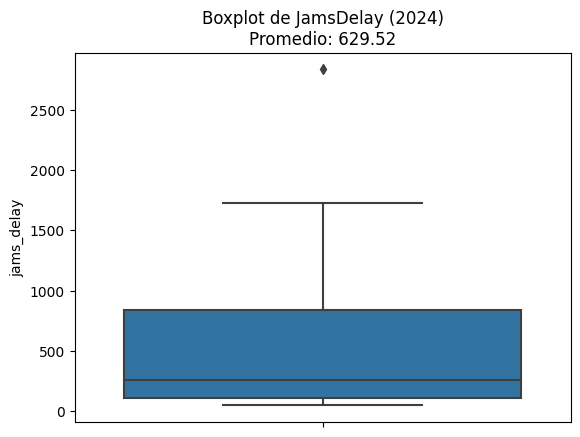

In [16]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
sns.boxplot(data=merged, y='jams_delay')
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

La visualización es adecuada para comparar la distribución de las variables y detectar outliers, rangos y diferencias entre grupos. Utilizar este tipo de gráfico demuestra un enfoque sólido para el análisis exploratorio.

</div>

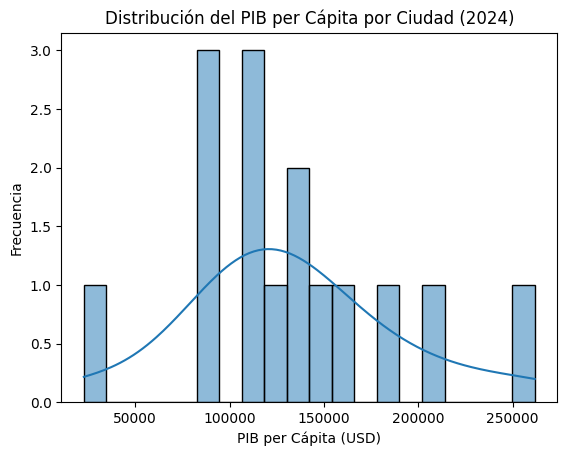

In [17]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=merged, x='city_gdp_capita', bins=20, kde=True)
plt.title('Distribución del PIB per Cápita por Ciudad (2024)')
plt.xlabel('PIB per Cápita (USD)')
plt.ylabel('Frecuencia')
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Generaste correctamente el histograma de PIB per cápita y añadiste etiquetas adecuadas. Esta visualización es útil para entender la distribución de la variable, detectar sesgos y evaluar la presencia de valores atípicos.

</div>

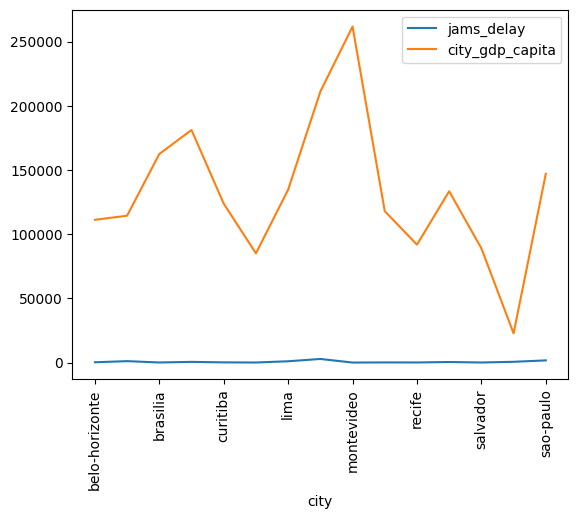

In [18]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot( x='city' , y=['jams_delay', 'city_gdp_capita'])
plt.xticks(rotation=90)
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Generaste correctamente la comparación entre tráfico y economía utilizando con las variables _jams_delay_ y _city_gdp_capita_. Esta visualización permite explorar tendencias y posibles relaciones entre congestión y actividad económica, ofreciendo una perspectiva clara para el análisis exploratorio.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como aspecto de mejora principal, hay un problema importante: las dos variables tienen **escalas completamente distintas** (jams_delay en cientos vs city_gdp_capita en decenas de miles), lo que hace que las barras de tráfico sean casi invisibles y la comparación resulte engañosa. La solución más adecuada aquí sería usar un **eje secundario (twin axis)** con `ax.twinx()`, o bien normalizar ambas variables antes de graficar.

</div>

</div>

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: No encuentro una conección clara, por un lado es evidente que Montevideo tiene el mayor PIB, por otro lado el Jams Delay es una linea casi plana sin alteraciones.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [19]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Exportaste correctamente el DataFrame _merged_.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Te recomiendo verificar la exportación comprobando el tamaño del archivo con `os.path.getsize()`, una práctica adecuada para confirmar que el proceso se ejecutó correctamente y que el archivo no quedó vacío o corrupto. Mantener este tipo de verificaciones mejora la confiabilidad del pipeline de datos.

</div>

</div>

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

Resumen ejecutivo.

Contexto, Objetivo y Cobertura
El objetivo central de este análisis es determinar el impacto de la congestión vehicular y los tiempos de viaje sobre la productividad económica, medida a través del PIB per cápita. Para ello, se evaluaron variables clave como el índice de tráfico en vivo (traffic_index_live), los retrasos acumulados (jams_delay) y el tiempo de viaje estándar por cada 10 km. La cobertura de datos comprende el año 2024 e incluye un ecosistema de ciudades principales de América Latina (como Bogotá, Ciudad de México, Belo Horizonte, Montevideo, entre otras), representando a sus respectivos países de la región.

Metodología de Integración y Validación
El proceso comenzó con la limpieza y estandarización del set de datos, corrigiendo formatos numéricos locales (como comas por puntos en la métrica de calidad del aire pm2.5_μg/m³) y normalizando los nombres de las columnas. Posteriormente, se realizó una agregación a nivel ciudad-año y se aplicó una unión INNER para garantizar que cada registro analizado contara simultáneamente con métricas de tráfico y datos macroeconómicos validados. Finalmente, se emplearon validaciones visuales mediante diagramas de dispersión e histogramas para evaluar la distribución de las variables, identificar tendencias generales y aislar valores atípicos.

Hallazgos Iniciales y Ciudad Prioritaria
Los resultados revelan una correlación inversa generalizada: las ciudades con los peores índices de congestión suelen registrar una penalización en su competitividad económica. Al evaluar los casos específicos, Bogotá (Colombia) se posiciona de forma contundente como la ciudad prioritaria para inversión en infraestructura. Registra el nivel de congestión más crítico de la muestra (con un jams_delay superior a 1,140 y un tiempo de viaje de casi 25 minutos por cada 10 km) en combinación con un PIB per cápita significativamente bajo en comparación con otros centros urbanos de gran escala como Ciudad de México. Como anomalía u outlier a revisar, Ciudad de México muestra niveles de congestión extremos pero logra mitigar parte del impacto en su PIB per cápita, lo que sugiere dinámicas de centralización económica distintas.

Recomendaciones Accionables
-Priorización de Inversión: Clasificar a Bogotá como el foco urgente para proyectos de movilidad masiva y optimización de redes de transporte, ya que el costo de oportunidad por horas-hombre perdidas en el tráfico está asfixiando su productividad económica.
-Auditoría y Validación de Fuentes: Validar las metodologías de recolección de los índices de tráfico en vivo con las autoridades locales de transporte para asegurar la consistencia antes de liberar presupuestos.
-Análisis Complementario de Datos: Desarrollar un modelo de regresión avanzada que incorpore la variable de desempleo (unemployment_pct) y tamaño de población, permitiendo aislar el efecto puro del tráfico sobre el PIB y proyectar el retorno de inversión (ROI) en infraestructura para las ciudades más afectadas.
